In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import genextreme as gev

from unseen import fileio
from unseen import process_utils
from unseen import eva

## Observations

In [24]:
obs_file = '/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/txx_ERA5_1940-2025_annual_PNW.nc'
var = 'tasmax'

In [25]:
obs_ds = fileio.open_dataset(obs_file)
obs_ds = obs_ds.dropna("time")

In [26]:
years = obs_ds["time"].dt.year.values
obs_df = pd.DataFrame(index=years)
obs_df[var] = obs_ds[var].values
obs_df['event_time'] = obs_ds['event_time'].values

In [27]:
ranked_obs_df = obs_df.sort_values([var,], ascending=False)
ranked_obs_df.head(n=10)

,tasmax,event_time
2021,39.514747,2021-06-29
1941,34.985207,1941-07-17
2006,33.832840,2006-07-22
2023,33.459787,2023-08-15
2015,33.443103,2015-06-28
2024,33.390364,2024-07-09
2022,33.381804,2022-07-28
1994,33.022524,1994-07-23
1998,32.974409,1998-07-27
2018,32.972533,2018-08-09


In [28]:
obs_max_event = obs_ds["tasmax"].values.max()
print(obs_max_event)

39.51474681653524


In [29]:
def detrend_obs(da_obs, pivot_year=2021):
    """Apply reference year detrending to observations.

    Reference: Atkins et al, 2025, doi:10.1038/s43247-025-02802-3
    """

    linear_fit = np.polyfit(da_obs.time.dt.year.values, da_obs.values, 1)
    linear_data = np.polyval(linear_fit, da_obs.time.dt.year.values)
    pivot_index = int(np.where(da_obs.time.dt.year.values == pivot_year)[0][0])
    linear_anomaly = linear_data[pivot_index] - linear_data 
 
    da_obs_detrended = da_obs + linear_anomaly
    da_obs_detrended.attrs = da_obs.attrs

    return da_obs_detrended, linear_data

In [30]:
obs_da_detrended, obs_linear_data = detrend_obs(obs_ds[var])

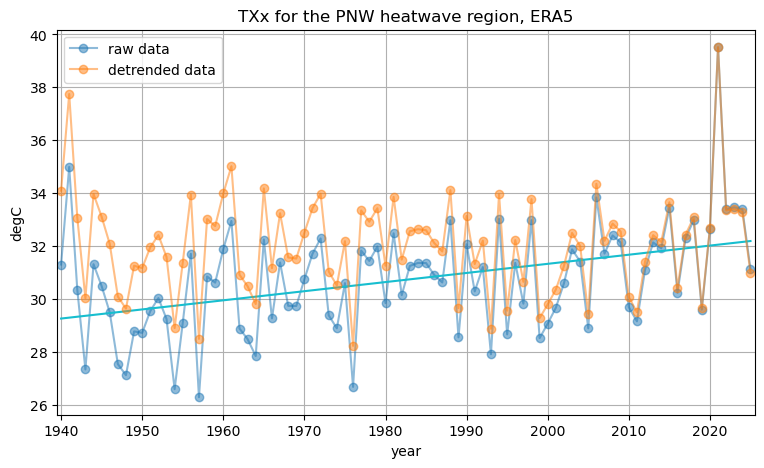

In [31]:
fig, ax = plt.subplots(figsize=[9, 5])
years = obs_ds['time'].dt.year.values
plt.plot(years, obs_ds[var].values, marker='o', label='raw data', color='tab:blue', alpha=0.5)
plt.plot(years, obs_linear_data, color='tab:cyan')
plt.plot(years, obs_da_detrended.values, marker='o', label='detrended data', color='tab:orange', alpha=0.5)
plt.xlim(years[0] - 0.5, years[-1] + 0.5)
plt.title('TXx for the PNW heatwave region, ERA5')
plt.ylabel('degC')
plt.xlabel('year')
plt.legend()
plt.grid()

In [32]:
def likelihood(data, event):
    """Calculate event likelihood"""

    shape, loc, scale = eva.fit_gev(data)
    probability = gev.sf(event, shape, loc=loc, scale=scale)
    return_period = 1. / probability
    percentile = (1 - probability) * 100
    print(f'{return_period:.0f} year return period')
    print(f'{percentile:.2f}% percentile')

    return shape, loc, scale

In [33]:
obs_shape, obs_loc, obs_scale = likelihood(obs_ds[var].values, obs_max_event)

inf year return period
100.00% percentile


/jobfs/172830262.gadi-pbs/ipykernel_3109780/2986732497.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  return_period = 1. / probability


In [34]:
obs_detrended_shape, obs_detrended_loc, obs_detrended_scale = likelihood(obs_da_detrended.values, obs_max_event)

1230 year return period
99.92% percentile


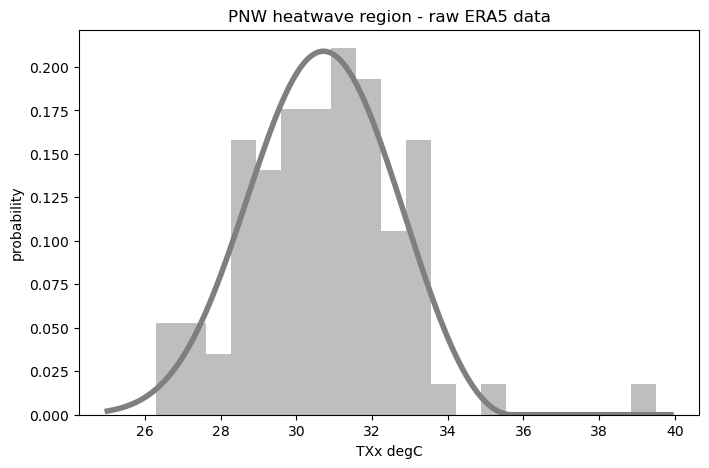

In [35]:
fig, ax = plt.subplots(figsize=[8, 5])
xvals = np.arange(25, 40, 0.1)
obs_ds[var].plot.hist(bins=20, density=True, color='tab:gray', alpha=0.5)
obs_pdf = gev.pdf(xvals, obs_shape, obs_loc, obs_scale)
plt.plot(xvals, obs_pdf, color='tab:gray', linewidth=4.0)
plt.xlabel('TXx degC')
plt.ylabel('probability')
plt.title('PNW heatwave region - raw ERA5 data')
plt.show()

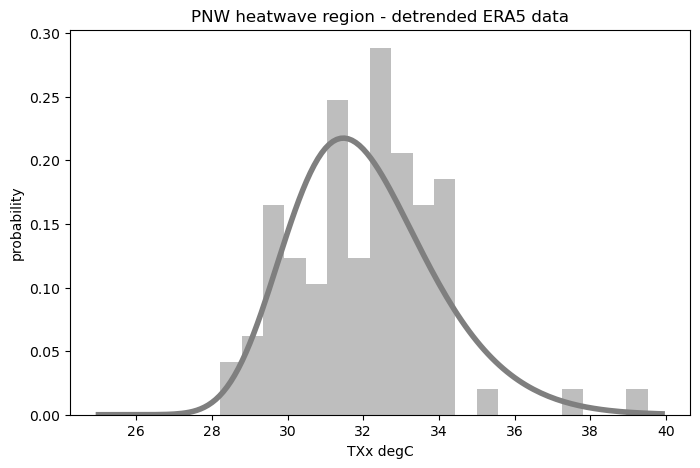

In [36]:
fig, ax = plt.subplots(figsize=[8, 5])
xvals = np.arange(25, 40, 0.1)
obs_da_detrended.plot.hist(bins=20, density=True, color='tab:gray', alpha=0.5)
obs_pdf_detrended = gev.pdf(xvals, obs_detrended_shape, obs_detrended_loc, obs_detrended_scale)
plt.plot(xvals, obs_pdf_detrended, color='tab:gray', linewidth=4.0)
plt.xlabel('TXx degC')
plt.ylabel('probability')
plt.title('PNW heatwave region - detrended ERA5 data')
plt.show()

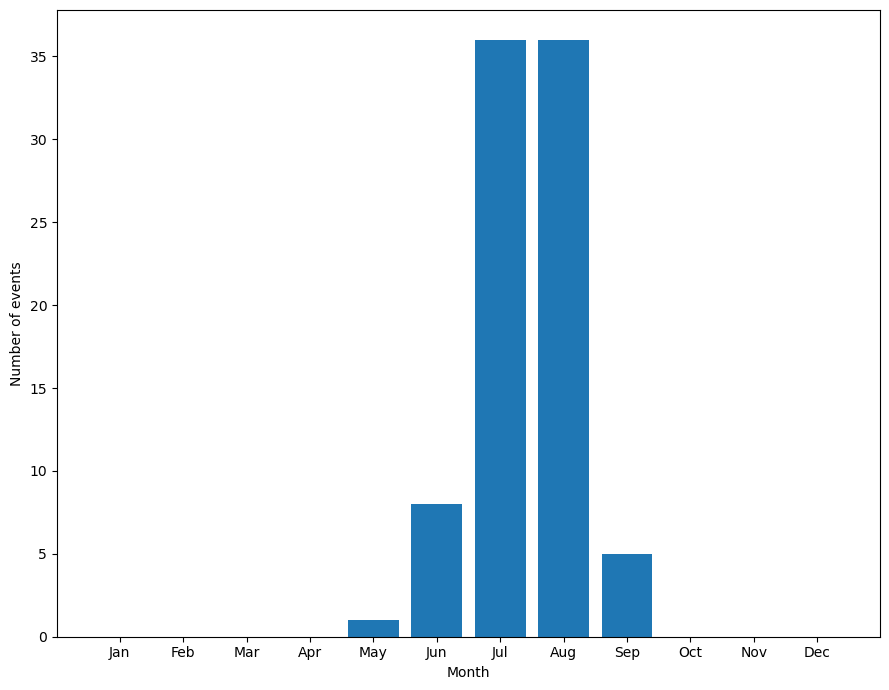

In [37]:
process_utils.plot_event_seasonality(obs_ds)